# Imports

In [1]:
import os
import sys

import numpy as np
import torch

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders, get_img_from_loader

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions
from utils.data import get_img_from_loader



In [2]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
lenet_model = LeNet(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
epoch = load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)
# load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(475, date="20251201")}', device)


[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


# Corruptions

In [3]:
corruptions = {
    'Original': lambda x: x,
    'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'Default Blur': lambda x: gaussian_blur(x, kernel_size=5),
    'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

# Распределение неопределенностей разных классов на разных искажениях

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from utils.uncertainty import mc_predict, quantify_uncertainties
from utils.corruptions import gaussian_blur

def corruptions_uncertainty(model, img, corruptions: dict = None, T=5):
    """Проверка изображения на разных типах искажений"""

    assert corruptions is not None

    FIXED_MAX = 0.3
    fig, axes = plt.subplots(2, len(corruptions.keys()), figsize=(15, 8))

    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img).unsqueeze(0)
        mc_preds = mc_predict(model, corrupted, mc_samples=T)
        mean_probs = mc_preds.mean(0)[0]
        pred, (total, alea, epis) = quantify_uncertainties(mc_preds)

        # Изображение
        axes[0, col].imshow(corrupted.cpu().squeeze(), cmap='gray')
        axes[0, col].set_title(f'{name}\nPred: {pred.item()}')
        axes[0, col].axis('off')

        uncertainties = {
            "AU": [alea[0, label, label].item() for label in range(10)],
            "EU": [epis[0, label, label].item() for label in range(10)],
        }

        bottom = np.zeros(10)
        for u_type, values in uncertainties.items():
            axes[1, col].bar(range(10), values, bottom=bottom, label=u_type)
            bottom += values

        axes[1, col].set_ylim(0, FIXED_MAX)
        axes[1, col].set_xticks(range(10))
        axes[1, col].set_xticklabels(range(10))
        axes[1, col].set_title(f'{name} Uncertainties')
        axes[1, col].set_xlabel('Class')
        axes[1, col].set_ylabel('Uncertainty')
        axes[1, col].legend(loc="upper right")


    plt.tight_layout()
    plt.show()


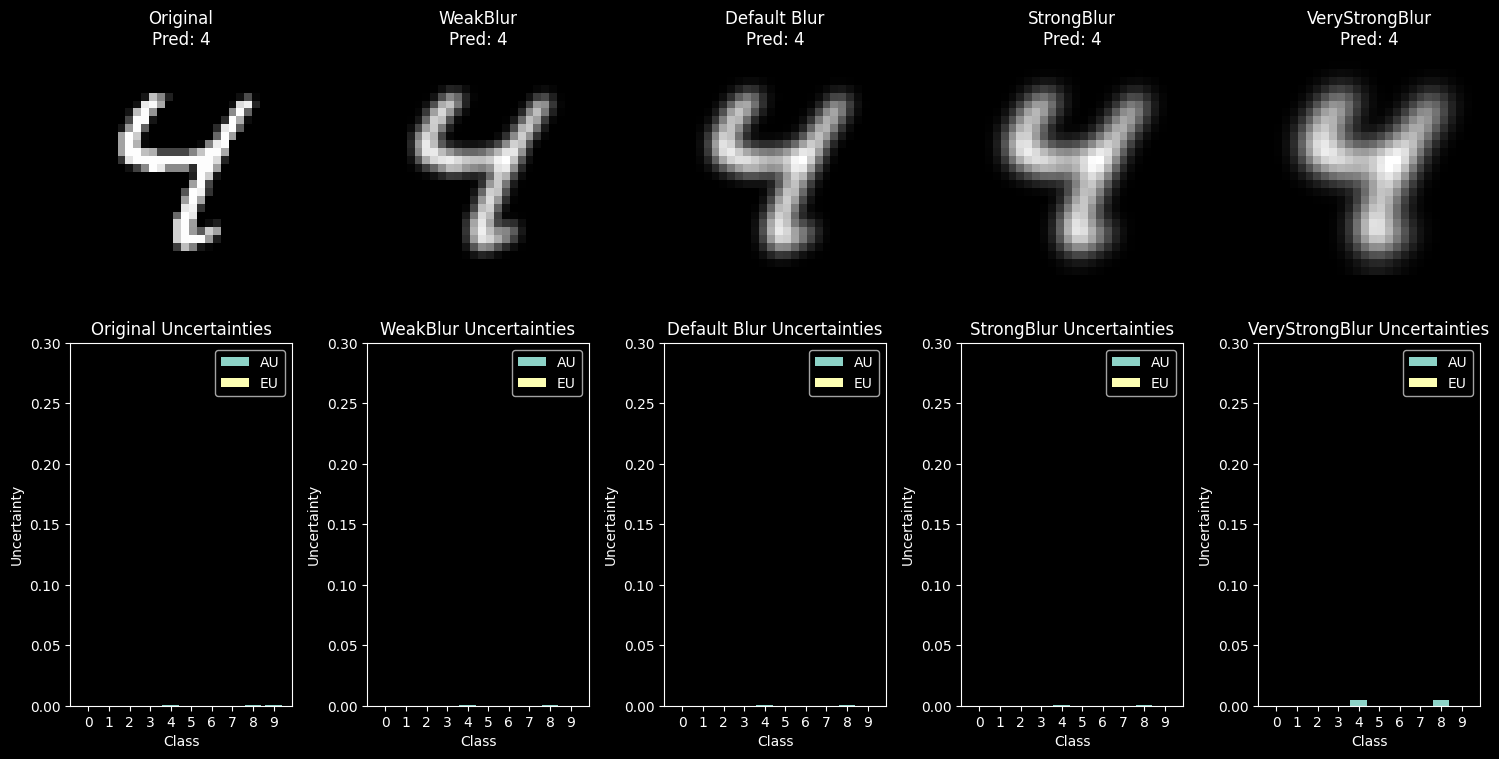

In [58]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

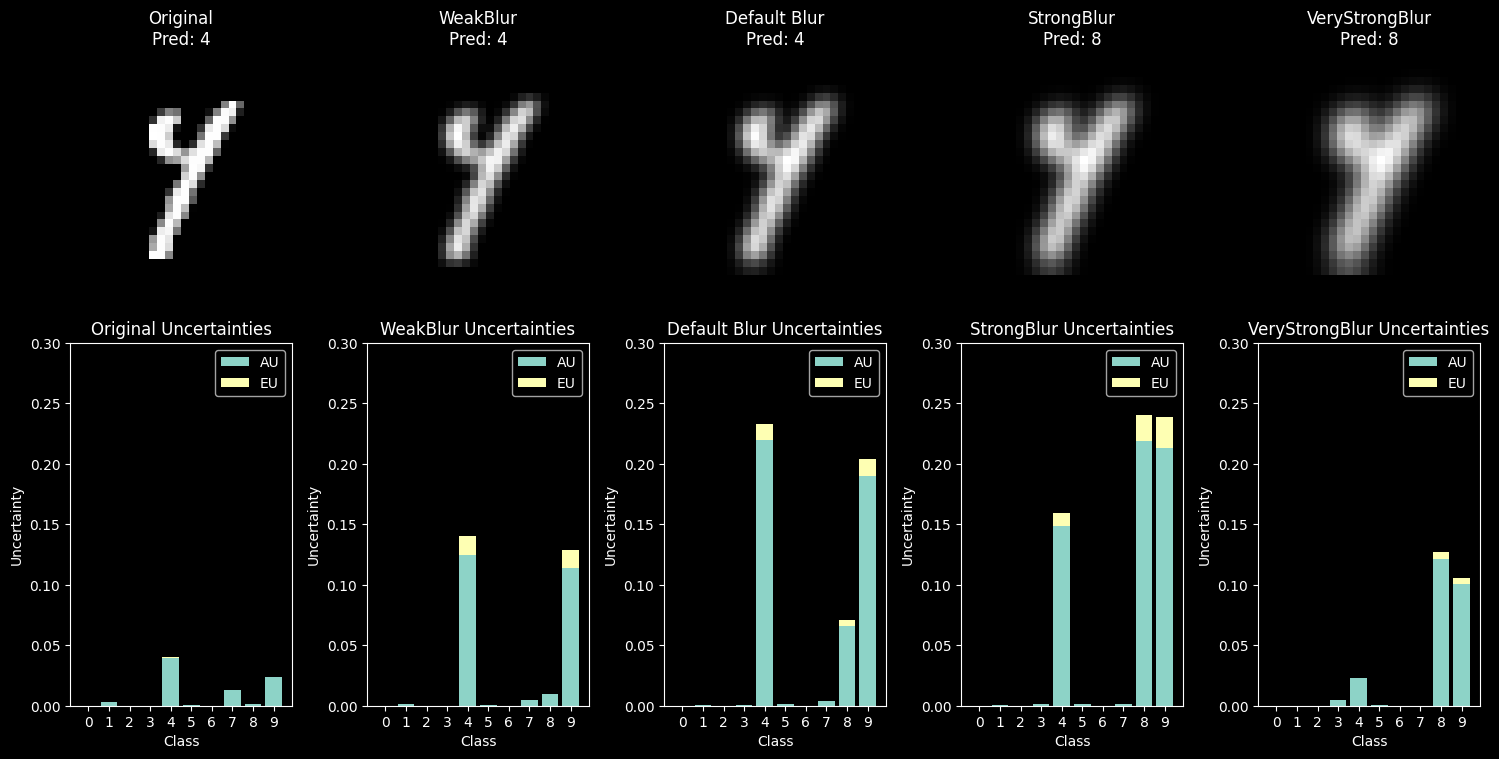

In [59]:
img, label = get_img_from_loader(test_loader, batch_idx=116, img_idx=10, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)


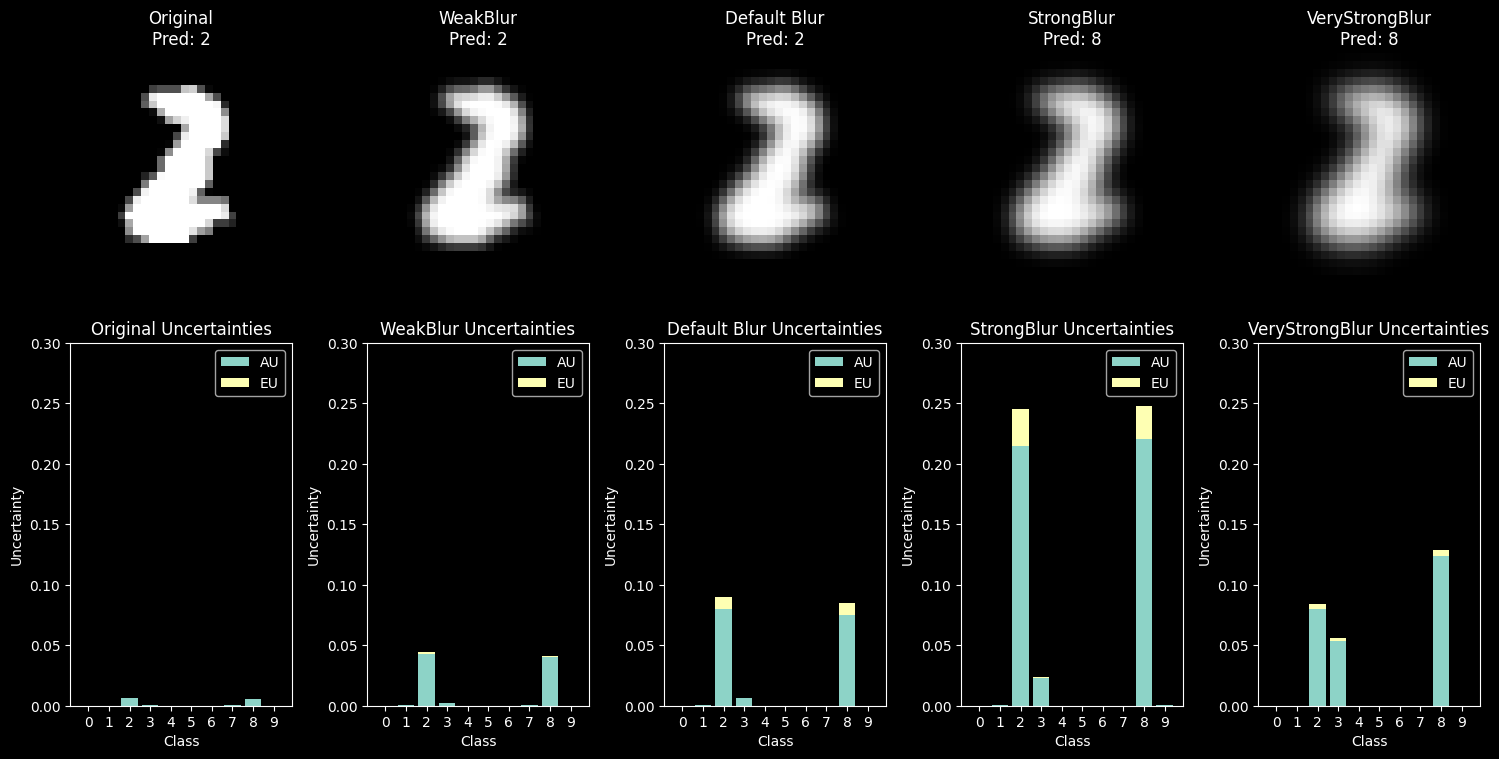

In [60]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)


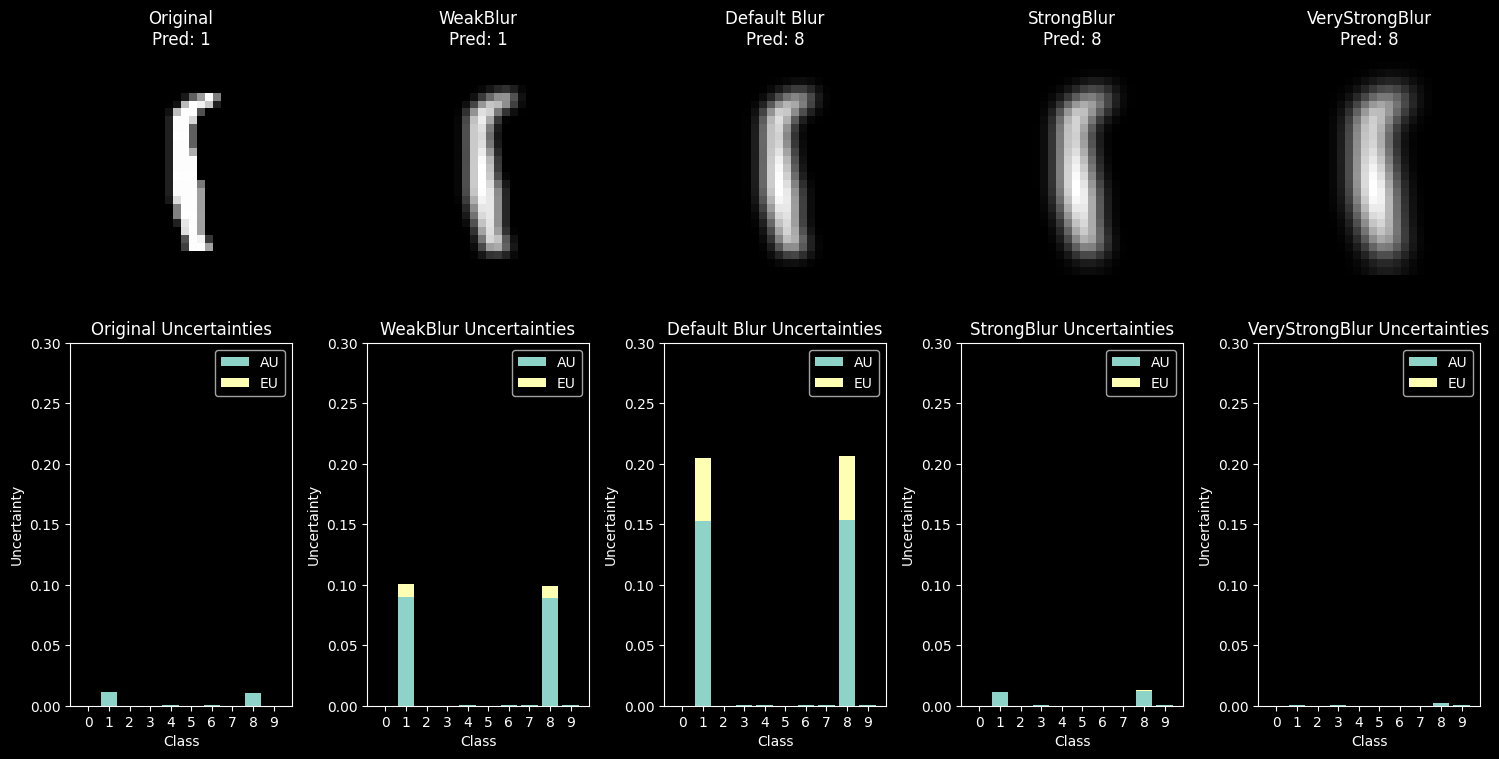

In [68]:
img, label = get_img_from_loader(test_loader, batch_idx=29, img_idx=3, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)

Random batch index: 426, image index: 8


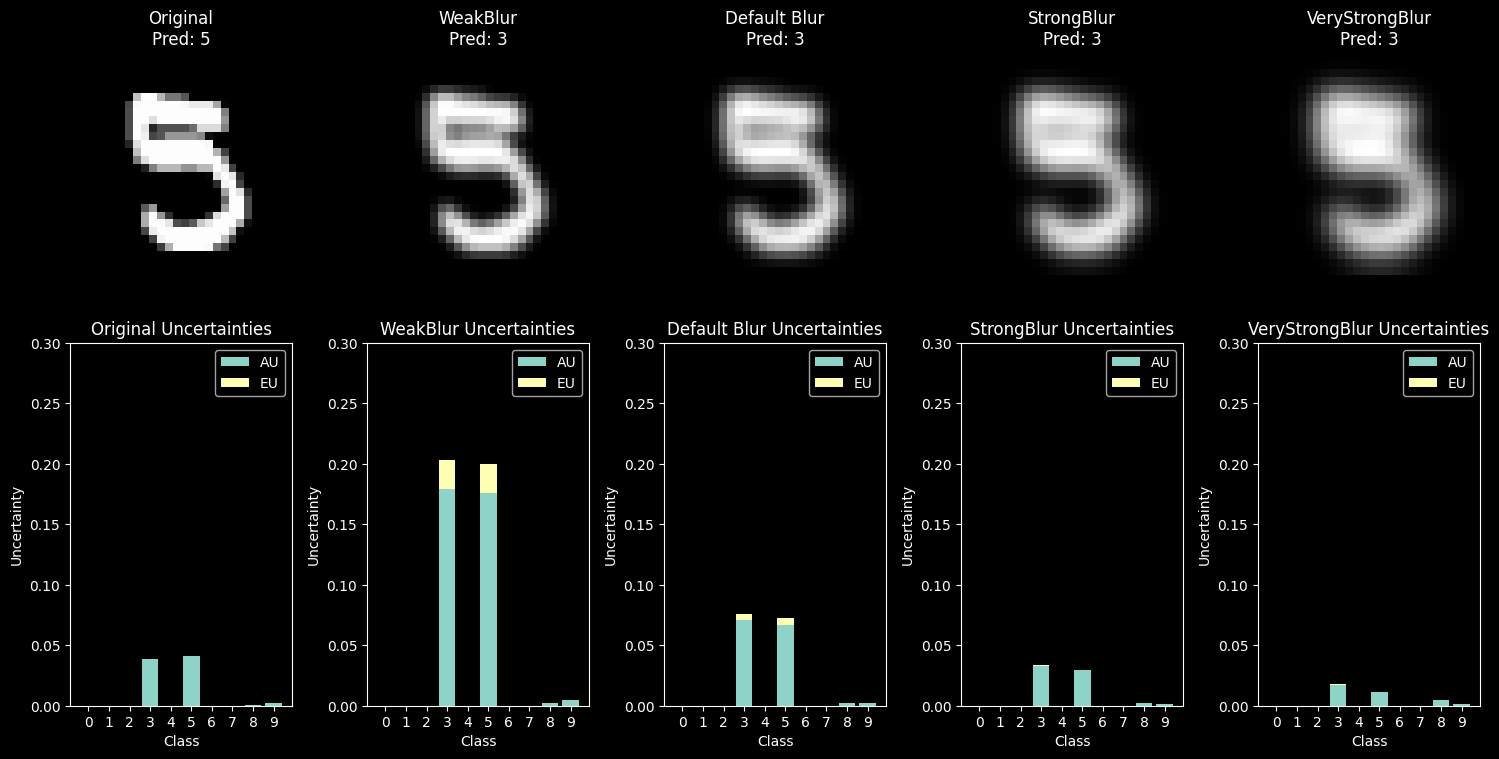

In [75]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
corruptions_uncertainty(lenet_model, img, corruptions, T=10)



# Тестирование неопределенности на разных искажениях

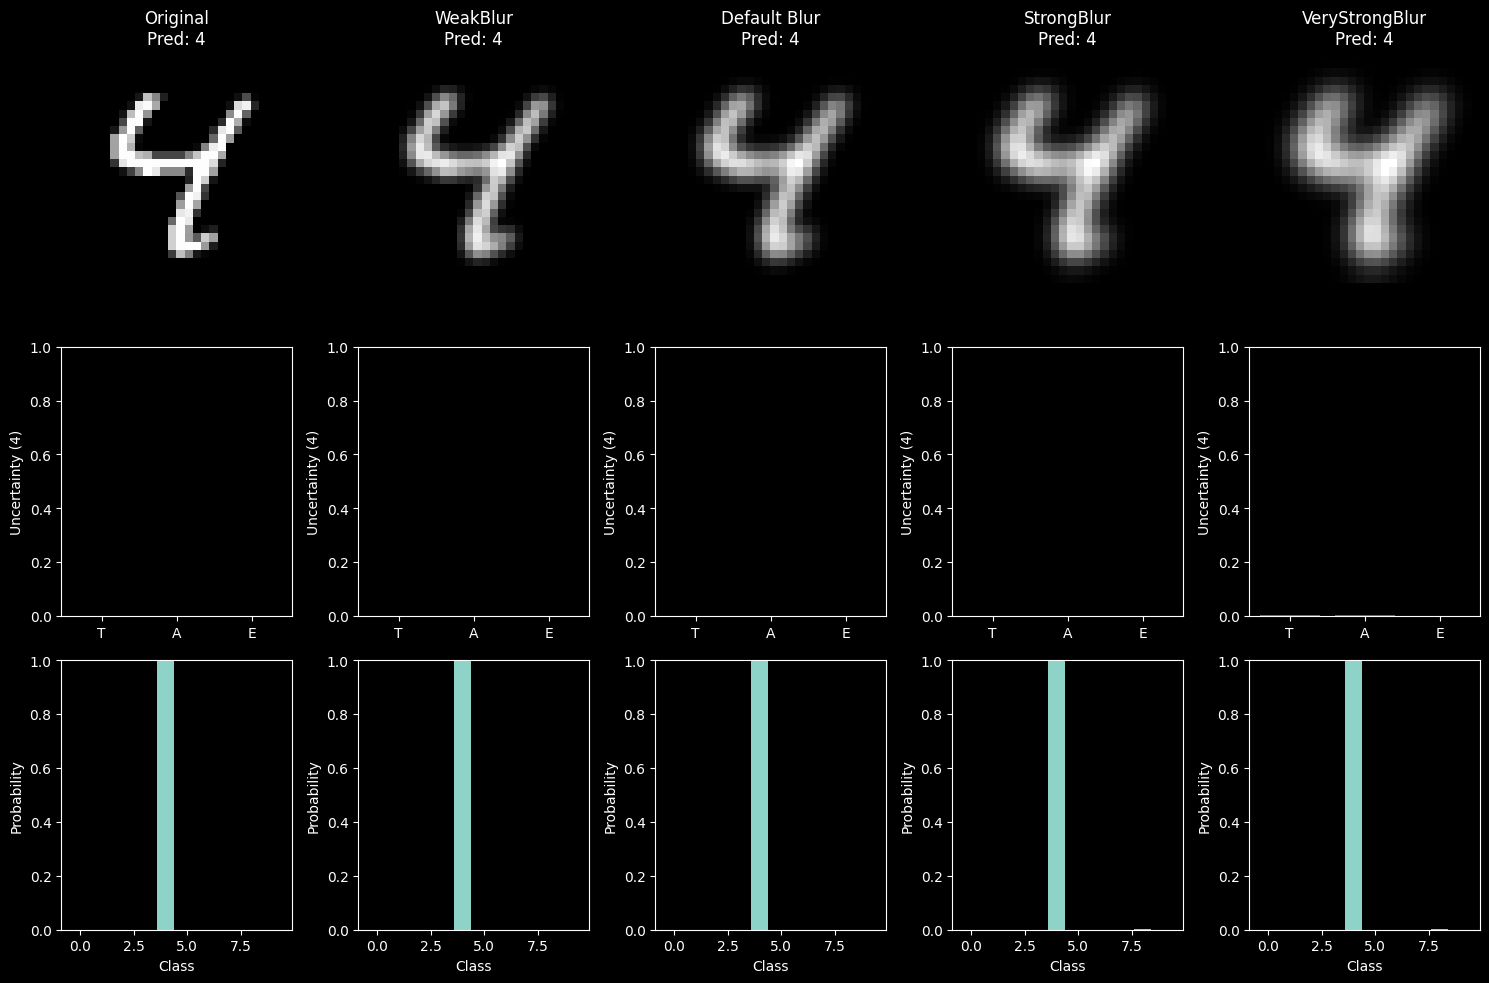

In [4]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

Random batch index: 265, image index: 6


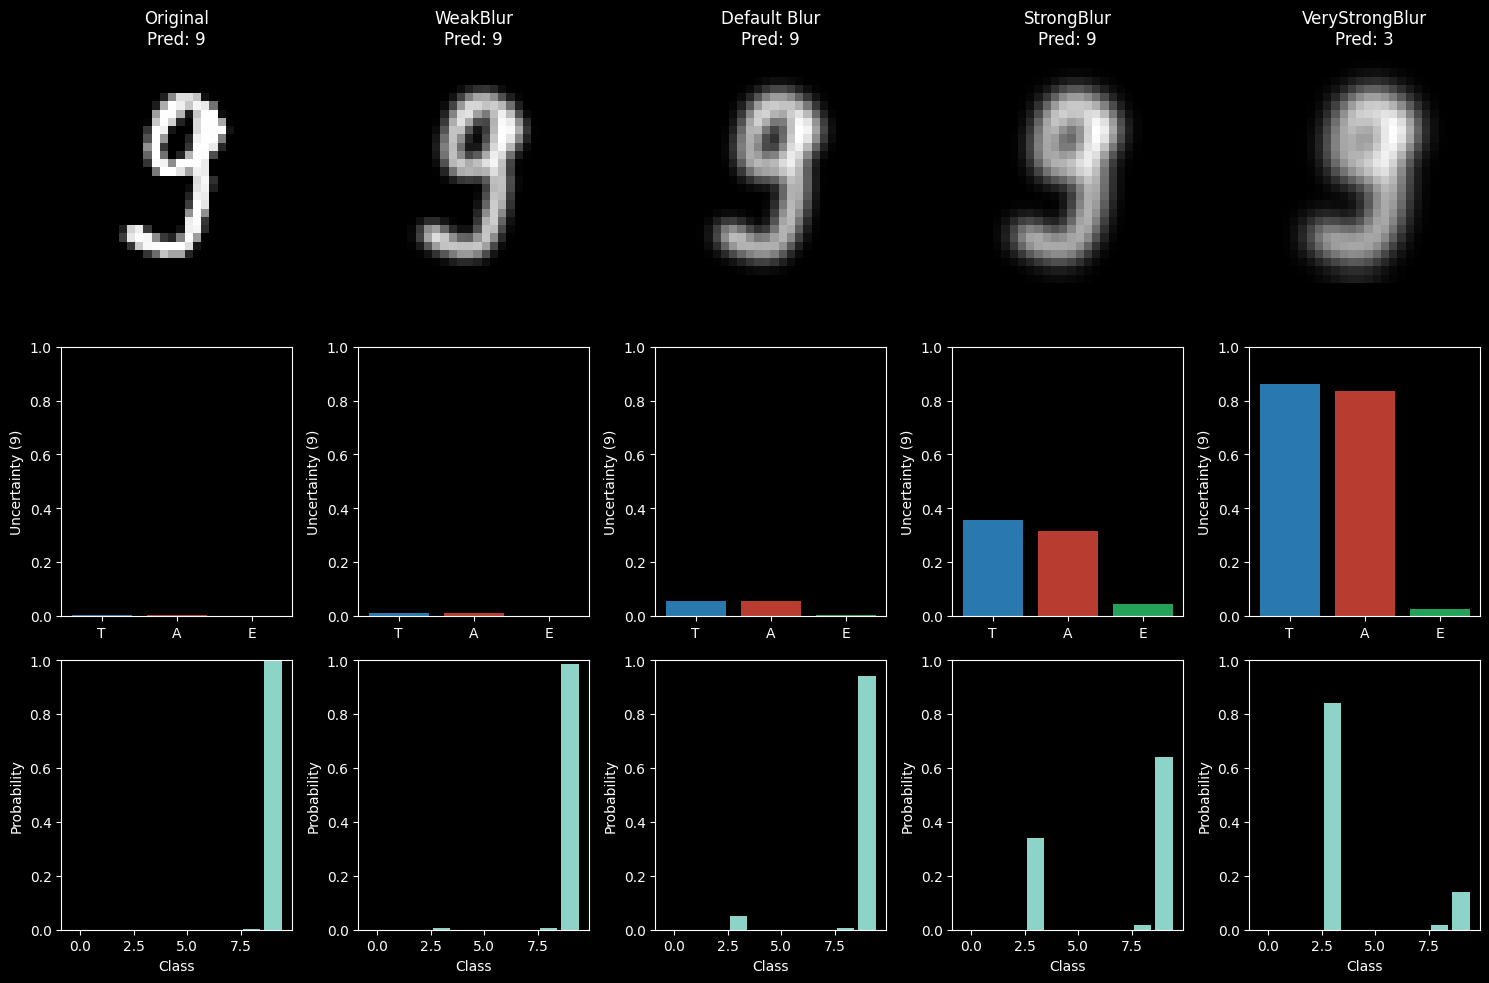

In [85]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

In [69]:
from matplotlib import pyplot as plt
from utils.uncertainty import mc_predict, quantify_uncertainties
from utils.corruptions import gaussian_blur

def corruptions_and_uncertainties_plot(model, img, label, corruptions: dict = None, T=5):
    """Зависимость алеаторной неопределенности от типа и степени искажения изображения."""

    assert corruptions is not None

    # Словарь: {class_label: {corruption_name: uncertainty_value}}
    data = {
        'true': dict(),
        'pred': dict()
    }

    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img).unsqueeze(0)
        mc_preds = mc_predict(model, corrupted, mc_samples=T)
        mean_probs = mc_preds.mean(dim=0).squeeze(0)
        pred, (_, alea, _) = quantify_uncertainties(mc_preds)

        # Для истинного класса
        true_prob = mean_probs[label].item()
        true_alea = alea[0, label, label].item()
        data['true'][name] = true_alea / true_prob

        # Для предсказанного класса
        pred_prob = mean_probs[pred].item()
        pred_alea = alea[0, pred, pred].item()
        data['pred'][name] = pred_alea / pred_prob

    # Визуализация
    fig, axes = plt.subplots(1, 2)
    # Изображение
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title(f'Number {label}')
    axes[0].axis('off')

    ax = axes[1]
    corruption_names = list(corruptions.keys())

    true_values = [data['true'][name] for name in corruption_names]
    pred_values = [data['pred'][name] for name in corruption_names]

    ax.plot(corruption_names, true_values, marker='o', label=f'True')
    ax.plot(corruption_names, pred_values, marker='s', label=f'Pred')

    ax.set_ylabel('Aleatoric Uncertainty')
    ax.set_xlabel('Corruption Type')
    ax.set_title('Uncertainty: True vs Predicted Class')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

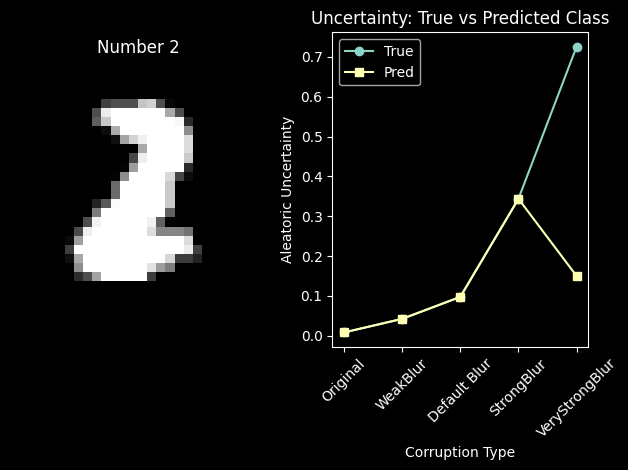

In [73]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_and_uncertainties_plot(lenet_model, img, label, corruptions, T=10)

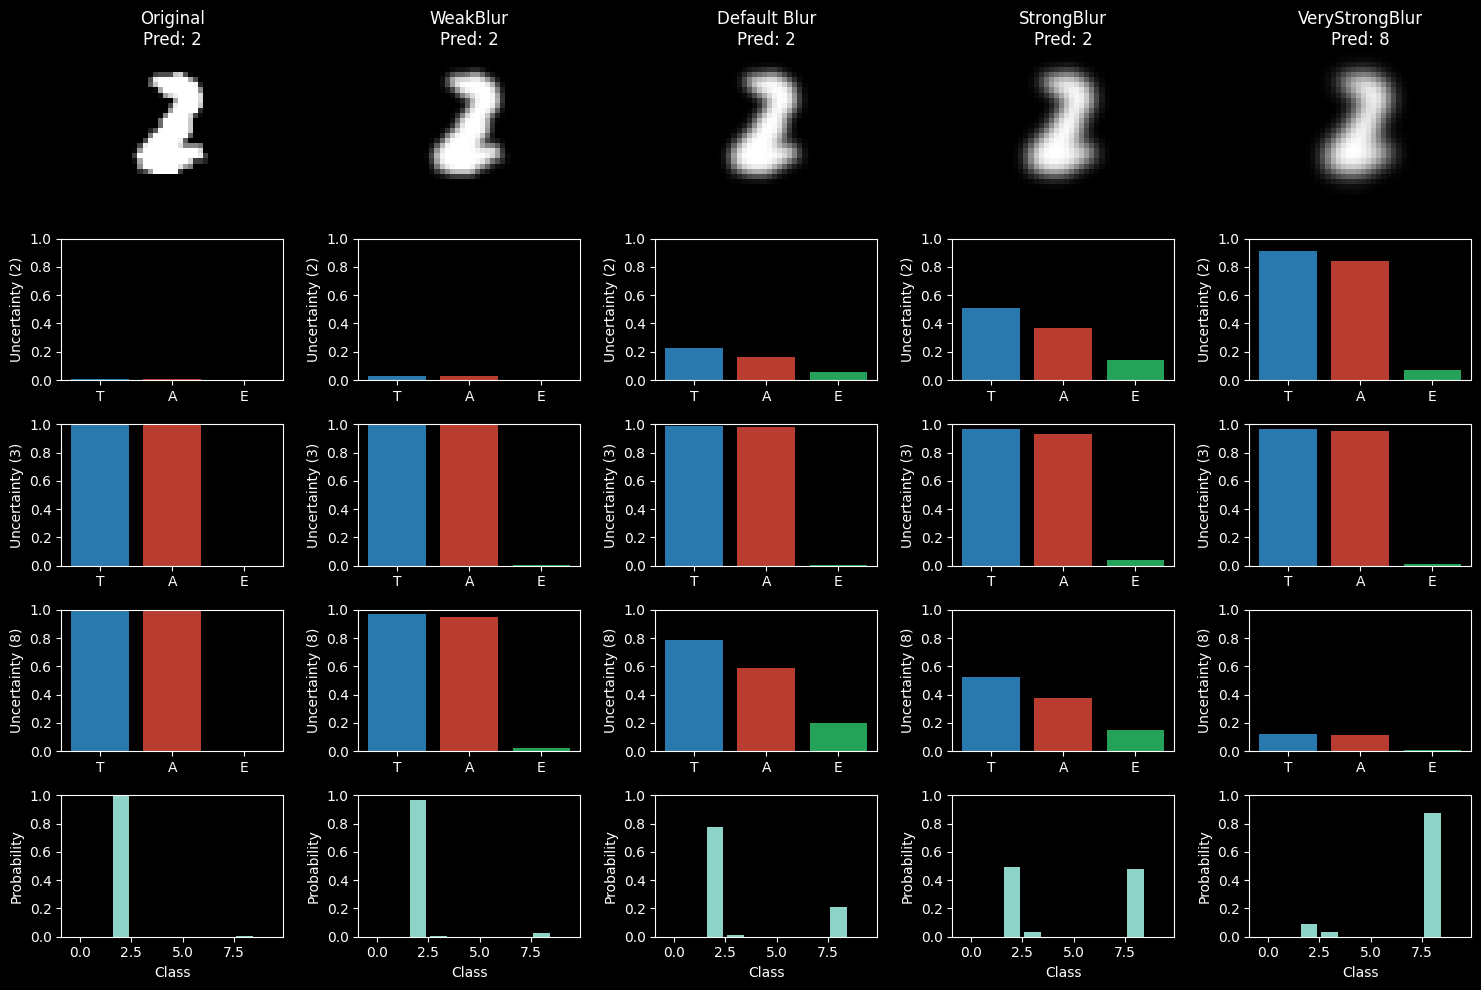

In [72]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

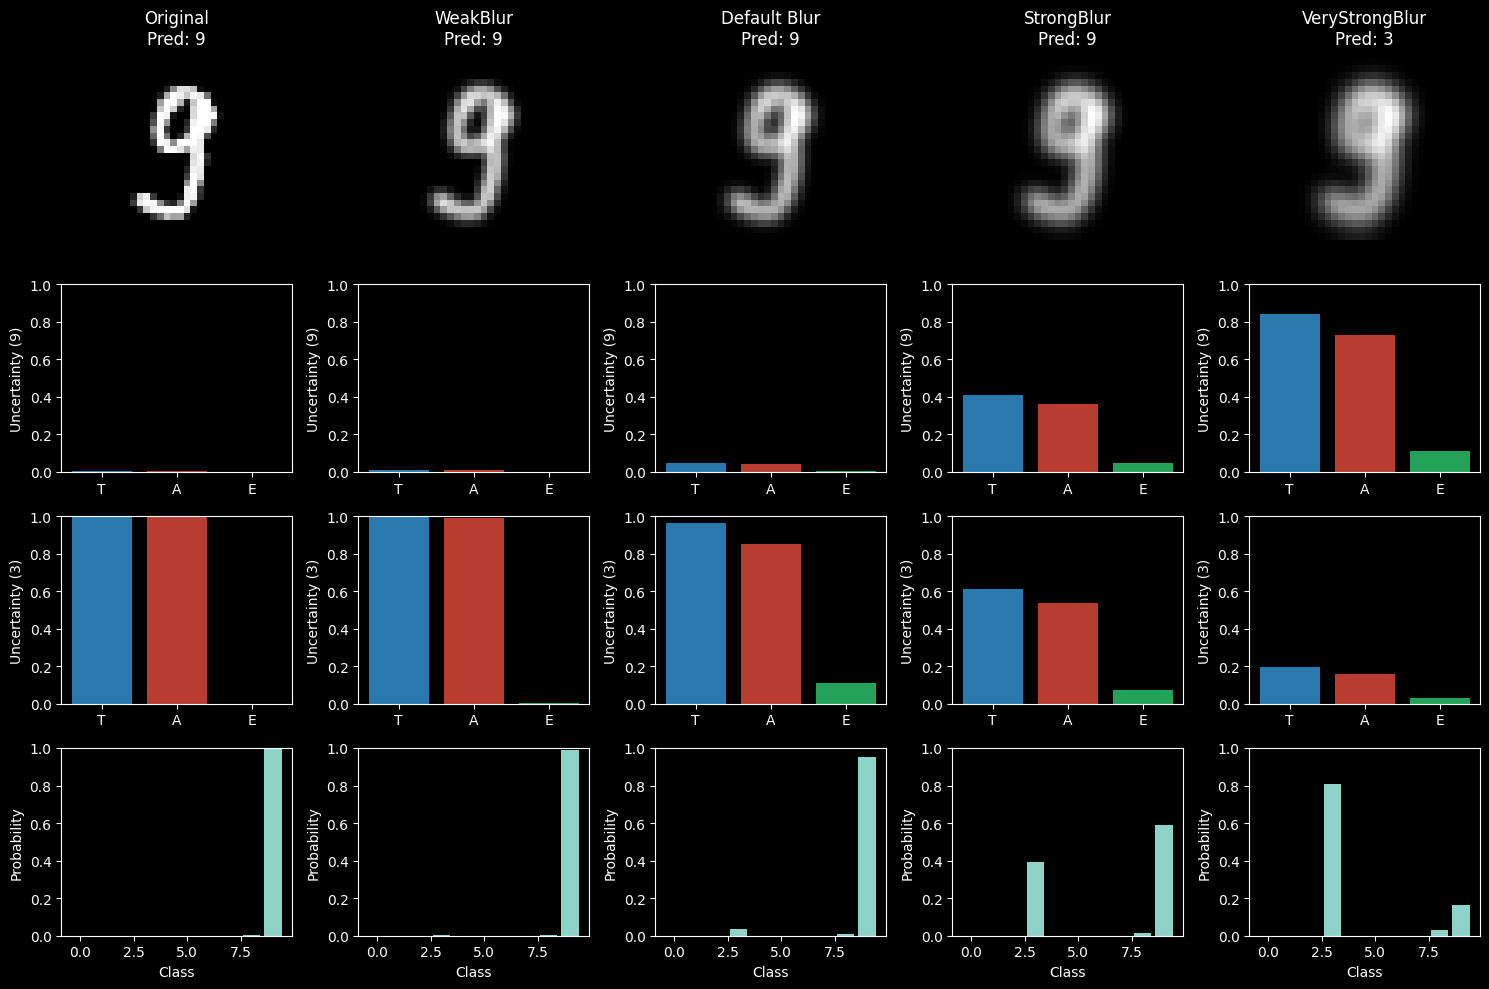

In [87]:
img, label = get_img_from_loader(test_loader, batch_idx=265, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3), T=10)

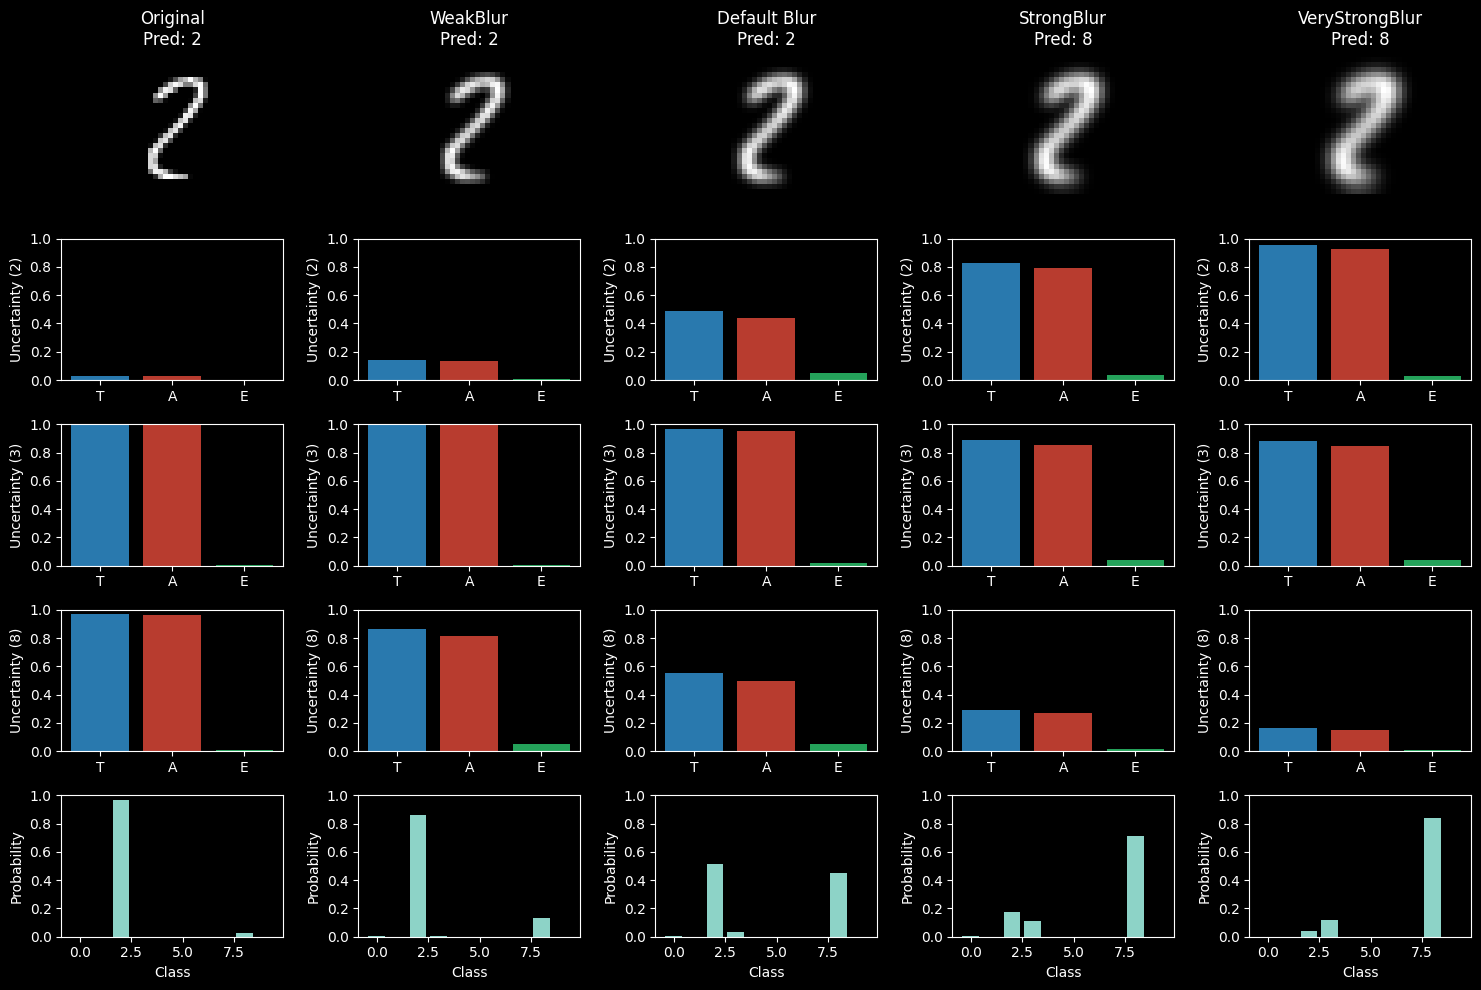

In [5]:
img, label = get_img_from_loader(test_loader, batch_idx=43, img_idx=11, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

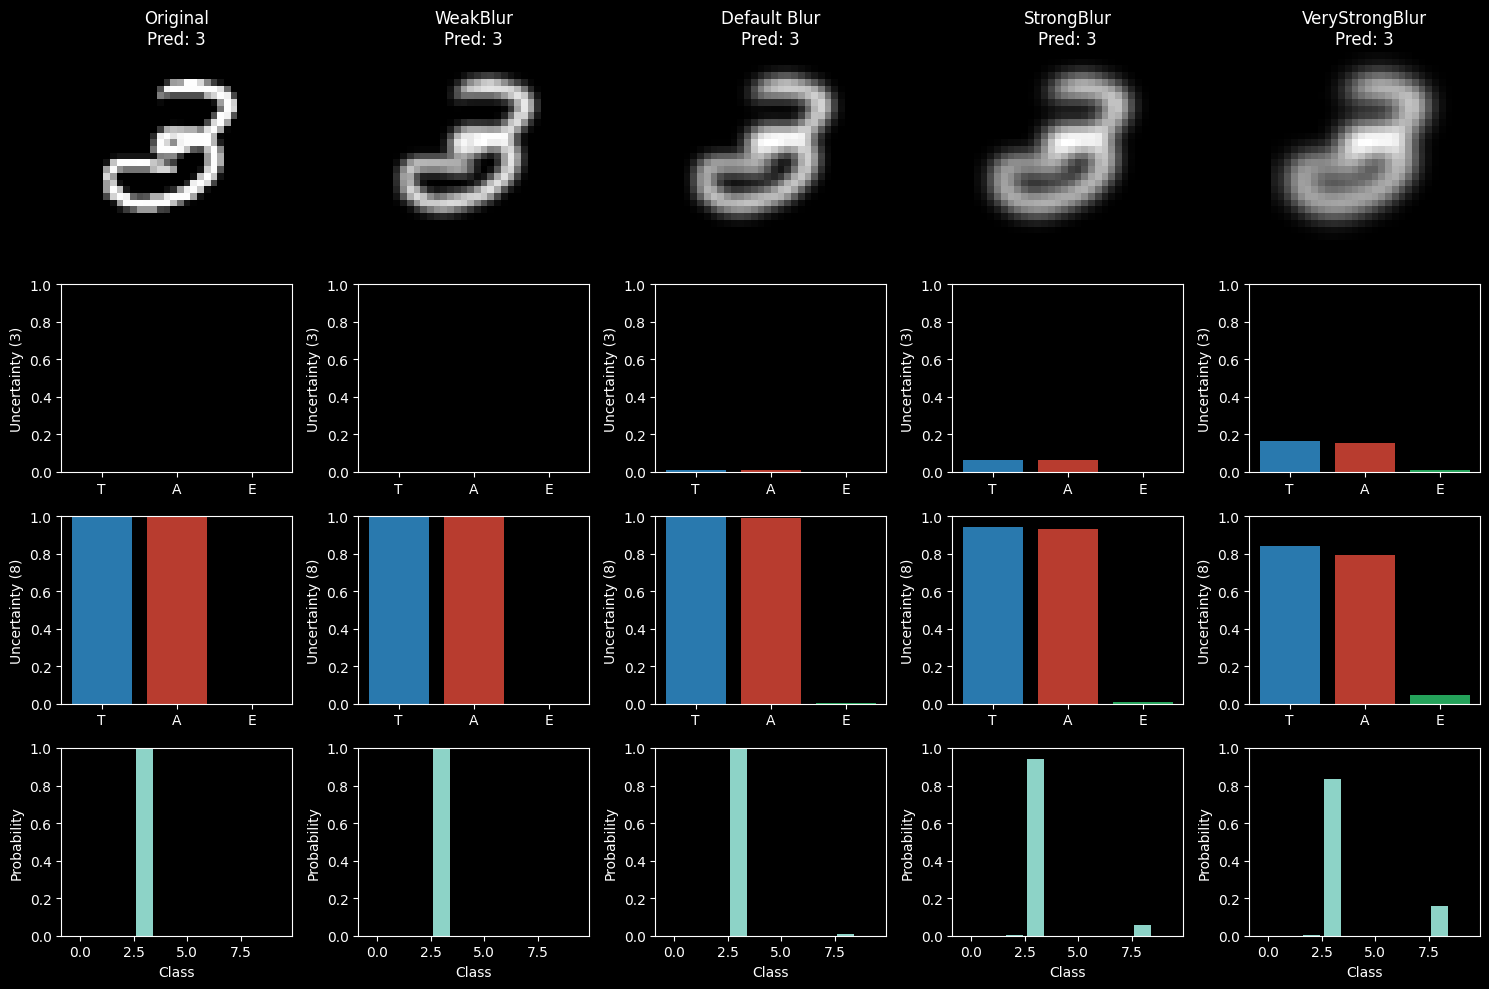

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=695, img_idx=12, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 8), T=10)

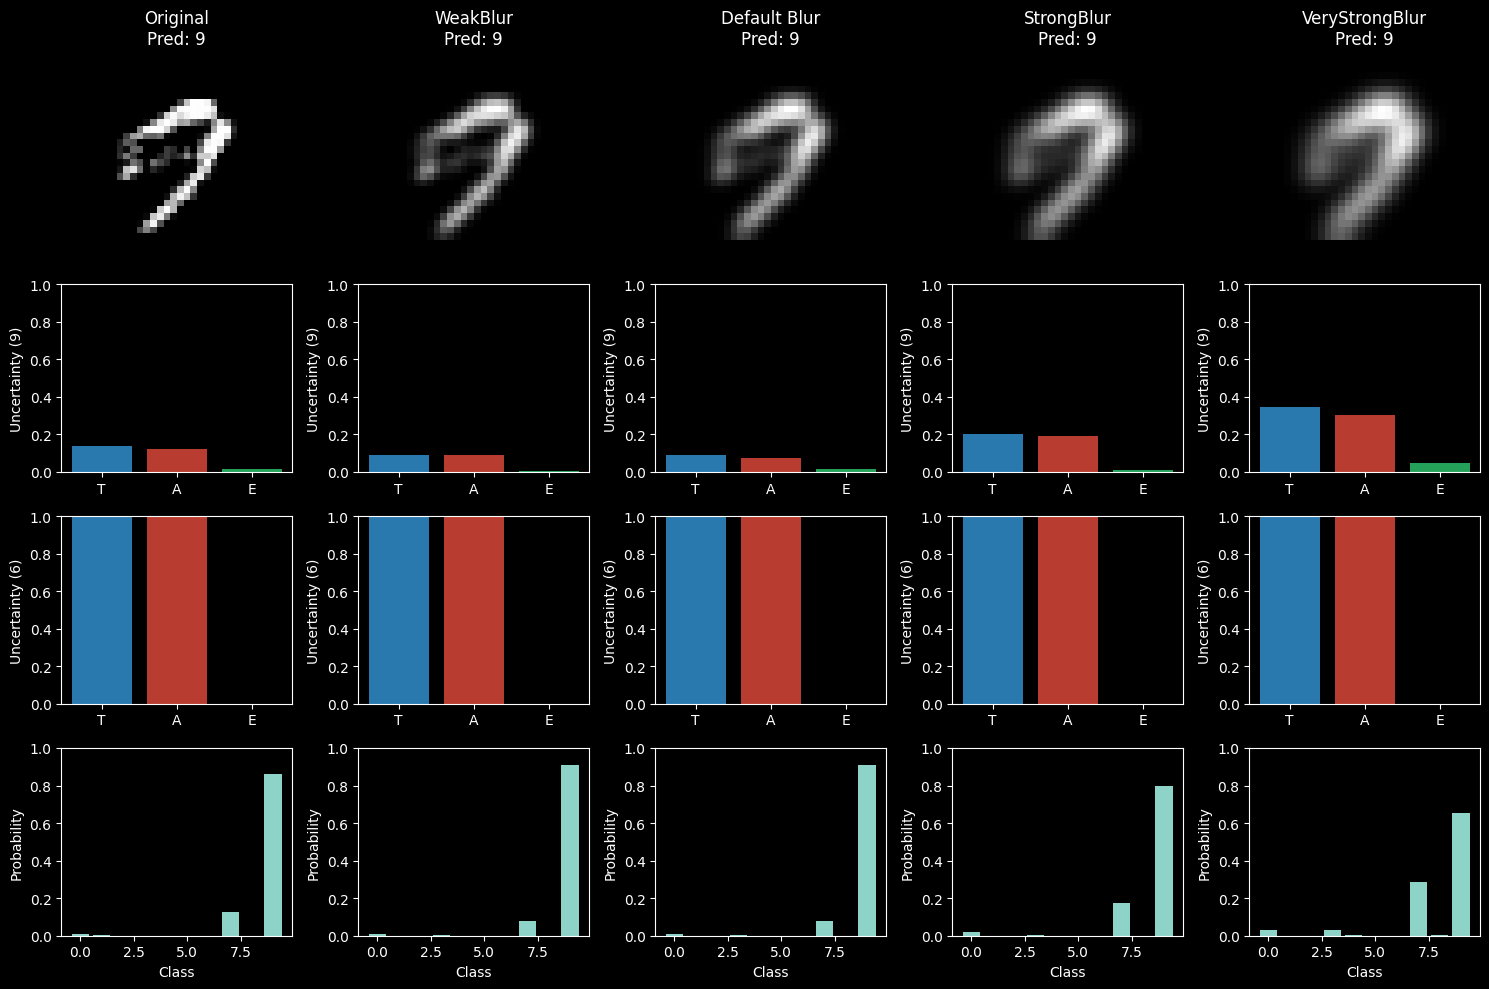

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=688, img_idx=10, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 6), T=10)

In [31]:
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10
# Цифра 9
img, label = get_img_from_loader(test_loader, batch_idx=688, img_idx=10, device=config.device)
mc_preds = mc_predict(lenet_model, corruptions['VeryStrongBlur'](img).unsqueeze(0), mc_samples=T)
pred, (total, alea, epis) = quantify_uncertainties(mc_preds)

In [11]:
total[0].shape

torch.Size([10, 10])

In [27]:
class_1 = 9
class_2 = 7
coef = (total[0, class_1, class_2])/ (total[0, class_1, class_1] * total[0, class_2, class_2])
coef

tensor(-4.5192, device='cuda:0')

In [20]:
class_1 = 9
class_2 = 2
coef = (total[0, class_1, class_2])/ (total[0, class_1, class_1] * total[0, class_2, class_2])
coef


tensor(-7.1861, device='cuda:0')

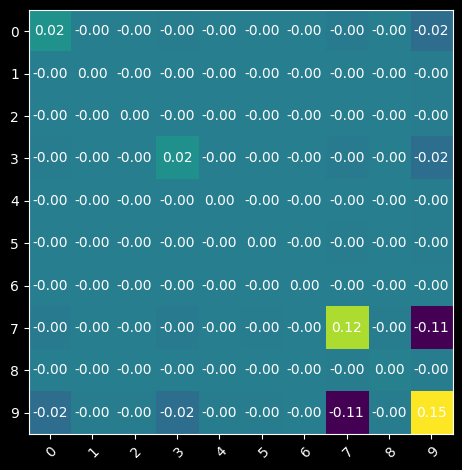

In [32]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
im = ax.imshow(total[0].cpu().numpy())


# Show all ticks and label them with the respective list entries
ax.set_xticks(range(10), labels=[i for i in range(10)],
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(10), labels=[i for i in range(10)])

# Loop over data dimensions and create text annotations.
for i in range(10):
    for j in range(10):
        value = total[0, i, j].item()
        if abs(value) > 0:
            text = ax.text(j, i, f"{value:.2f}",
                           ha="center", va="center", color="w")
        else:
            text = ax.text(j, i, "",
                           ha="center", va="center", color="w")

fig.tight_layout()
plt.show()

In [99]:
from utils.uncertainty import mc_predict, quantify_uncertainties
img, label = get_img_from_loader(test_loader, batch_idx=688, img_idx=10, device=config.device)
T = 10
mc_preds = mc_predict(lenet_model, corruptions['Original'](img).unsqueeze(0), mc_samples=10)
mc_preds.shape

torch.Size([10, 1, 10])

In [106]:
import torch.nn.functional as F

print(F.cross_entropy(mc_preds[0], mc_preds[0], reduction='none').shape)
torch.tensor([F.cross_entropy(mc_preds[t], mc_preds[t], reduction='none') for t in range(T)]).mean()

torch.Size([1])


tensor(1.6863)

In [110]:
torch.tensor([F.kl_div(mc_preds[0], mc_preds[0], reduction='batchmean') for t in range(T)]).mean()

tensor(-1.1195)